In [1]:
# !pip3 install -r ../requirements.txt

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print('✅ Biblioteki załadowane')

✅ Biblioteki załadowane


# Stabilność centroidu naukowca w zależności od liczby prac

Badamy, jak bardzo centroid (profil embeddingowy) naukowca zmienia się w zależności od tego,
ile losowo wybranych prac bierzemy pod uwagę.

**Eksperyment:**
- Bierzemy 3 / 5 / 10 / wszystkie prace — dla każdego rozmiaru powtarzamy losowanie 3 razy.
- Budujemy centroid (średnią embeddingów) dla każdego zestawu.
- Porównujemy centroidy przez PCA i podobieństwo cosinusowe.

**Naukowiec:** prof. UAM dr hab. Tomasz Górecki (ORCID: `0000-0002-9969-5257`)

In [3]:
# ── Konfiguracja ───────────────────────────────────────────────────────────────
SCIENTISTS_FILE = '../../data/scientists_with_identifiers.csv'
WORKS_FILE      = '../../data/titles_with_abstracts.csv'
EMBEDDINGS_DIR  = '../../embeddings'

MODELS = {
    'MiniLM-L6':          'all-MiniLM-L6-v2',
    'Specter':             'allenai/specter', #768
    'MPNet-Base':          'all-mpnet-base-v2', #768
    'Multilingual-MiniLM': 'paraphrase-multilingual-MiniLM-L12-v2',
    'MiniLM-L12':          'all-MiniLM-L12-v2',
    'BGE-Small':           'BAAI/bge-small-en-v1.5',
}

EMB_TYPE   = 'title'    # tylko tytuły
TARGET_DIM = 384        # wymiar MiniLM-L6; do tego rozmiaru sprowadzamy wszystkie modele

TARGET_ORCID = '0000-0002-9969-5257'
TARGET_NAME  = 'prof. UAM dr hab. Tomasz Górecki'

SAMPLE_SIZES = [3, 5, 10]
N_REPEATS    = 3
RANDOM_SEED  = 42

print('📋 Konfiguracja:')
print(f'   Naukowiec:       {TARGET_NAME}')
print(f'   ORCID:           {TARGET_ORCID}')
print(f'   Modele:          {list(MODELS.keys())}')
print(f'   Typ embeddingu:  {EMB_TYPE}')
print(f'   Docelowy wymiar: {TARGET_DIM}')
print(f'   Rozmiary próbek: {SAMPLE_SIZES} + [all], powtórzeń: {N_REPEATS}')

📋 Konfiguracja:
   Naukowiec:       prof. UAM dr hab. Tomasz Górecki
   ORCID:           0000-0002-9969-5257
   Modele:          ['MiniLM-L6', 'Specter', 'MPNet-Base', 'Multilingual-MiniLM', 'MiniLM-L12', 'BGE-Small']
   Typ embeddingu:  title
   Docelowy wymiar: 384
   Rozmiary próbek: [3, 5, 10] + [all], powtórzeń: 3


In [4]:
# ── Wczytanie danych ───────────────────────────────────────────────────────────
df_scientists = pd.read_csv(SCIENTISTS_FILE)
df_works      = pd.read_csv(WORKS_FILE)

# Standaryzacja ORCID (usuń prefix URL jeśli istnieje)
def clean_orcid(orcid):
    if pd.isna(orcid):
        return None
    return str(orcid).strip().replace('https://orcid.org/', '').replace('http://orcid.org/', '')

df_scientists['clean_orcid'] = df_scientists['orcid'].apply(clean_orcid)
df_works['clean_orcid']      = df_works['main_author_orcid'].apply(clean_orcid)

# Prace Góreckiego
gorecki_works = df_works[df_works['clean_orcid'] == TARGET_ORCID].copy()
gorecki_ids   = gorecki_works['openalex_id'].tolist()

print(f'✅ Dane wczytane.')
print(f'   Łącznie naukowców: {len(df_scientists)}')
print(f'   Łącznie prac:      {len(df_works)}')
print(f'\n   Prace {TARGET_NAME}: {len(gorecki_ids)}')
print(f'\n   Przykładowe tytuły:')
for t in gorecki_works['title'].head(5):
    print(f'     • {t[:90]}')

✅ Dane wczytane.
   Łącznie naukowców: 164
   Łącznie prac:      3440

   Prace prof. UAM dr hab. Tomasz Górecki: 114

   Przykładowe tytuły:
     • Using derivatives in time series classification
     • A comparison of tests for the one-way ANOVA problem for functional data
     • fdANOVA: an R software package for analysis of variance for univariate and multivariate fu
     • Classification of commercial apple juices based on multivariate analysis of their chemical
     • Food production and resource use of urban farms and gardens: a five-country study


In [5]:
# ── Funkcje pomocnicze ─────────────────────────────────────────────────────────

def load_work_embedding(openalex_id: str, model_short: str, emb_type: str) -> np.ndarray | None:
    """Wczytuje embedding pojedynczej pracy z pliku per-work pkl."""
    model_norm = MODELS[model_short].replace('/', '-').replace('\\', '-')
    subdir     = 'titles' if emb_type == 'title' else 'abstracts'
    filepath   = os.path.join(EMBEDDINGS_DIR, subdir, model_norm,
                              f'{openalex_id}_{emb_type}.pkl')
    if not os.path.exists(filepath):
        return None
    with open(filepath, 'rb') as f:
        return pickle.load(f)['embedding']


def build_centroid(embeddings: list[np.ndarray]) -> np.ndarray:
    """Centroid = nieznormalizowana średnia embeddingów."""
    return np.mean(np.stack(embeddings), axis=0)


def load_all_embeddings_for_scientist(orcid_ids: list[str],
                                      model_short: str,
                                      emb_type: str) -> dict[str, np.ndarray]:
    """Zwraca {openalex_id: embedding} dla dostępnych prac naukowca."""
    result = {}
    for oid in orcid_ids:
        emb = load_work_embedding(oid, model_short, emb_type)
        if emb is not None:
            result[oid] = emb
    return result


# ── resize_embedding (identyczna z concatenate_embedings_experiment.ipynb) ────
# Cache macierzy projekcji – ta sama para (input_dim, target_dim) zawsze da
# identyczną macierz, dzięki czemu wyniki są powtarzalne między wywołaniami.
_projection_cache: dict = {}

def resize_embedding(embedding: np.ndarray, target_dim: int, seed: int = 42) -> np.ndarray:
    """
    Zmienia wymiar embeddingu przez losową projekcję liniową (Johnson-Lindenstrauss)
    i normalizuje wynik L2.

    Projekcja liniowa jest operacją liniową, więc:
      resize(mean(x_i)) == mean(resize(x_i))
    Można więc resize'ować gotowe centroidy zamiast każdego embeddingu z osobna.
    """
    embedding = np.asarray(embedding, dtype=np.float32)
    input_dim = embedding.shape[0]

    if input_dim == target_dim:
        norm = np.linalg.norm(embedding)
        return embedding / norm if norm > 0 else embedding

    cache_key = (input_dim, target_dim, seed)
    if cache_key not in _projection_cache:
        rng_proj = np.random.RandomState(seed + input_dim * 100_000 + target_dim)
        # Skalowanie 1/sqrt(target_dim) zachowuje przybliżone normy (JL lemma)
        _projection_cache[cache_key] = (
            rng_proj.randn(input_dim, target_dim).astype(np.float32) / np.sqrt(target_dim)
        )

    projected = embedding @ _projection_cache[cache_key]
    norm = np.linalg.norm(projected)
    return projected / norm if norm > 0 else projected


# ── Test ──────────────────────────────────────────────────────────────────────
_v = np.random.randn(768).astype(np.float32)
print('✅ Funkcje pomocnicze gotowe.')
print(f'   Test resize_embedding: 768 → 384: shape={resize_embedding(_v, 384).shape}')

✅ Funkcje pomocnicze gotowe.
   Test resize_embedding: 768 → 384: shape=(384,)


In [6]:
# ── Główny eksperyment: budowanie centroidów ──────────────────────────────────
#
# centroids[model_short] = lista dicts:
#   {'label': str, 'size': int, 'repeat': int, 'centroid': np.ndarray (TARGET_DIM,)}
#
# Ponieważ resize_embedding jest liniowe: resize(mean(x_i)) == mean(resize(x_i))
# możemy resize'ować każdy embedding pracy → budować centroid ze zresizowanych wektorów.

rng = np.random.default_rng(RANDOM_SEED)

centroids = {}

for model_short in MODELS:
    # 1. Wczytaj embeddingi wszystkich dostępnych prac
    emb_map = load_all_embeddings_for_scientist(gorecki_ids, model_short, EMB_TYPE)
    all_ids = list(emb_map.keys())

    if len(all_ids) == 0:
        print(f'⚠  Brak embeddingów: {model_short}')
        continue

    raw_dim = next(iter(emb_map.values())).shape[0]

    # 2. Jeśli dim != TARGET_DIM — zresizuj każdy embedding pracy (proj. liniowa)
    if raw_dim != TARGET_DIM:
        emb_map_r = {oid: resize_embedding(emb, TARGET_DIM) for oid, emb in emb_map.items()}
        print(f'   {model_short:12s}  dim {raw_dim} → {TARGET_DIM}  (resize_embedding)')
    else:
        emb_map_r = emb_map
        print(f'   {model_short:12s}  dim {raw_dim} (bez redukcji)')

    entries = []

    # 3. Losowe podzbiory: 3, 5, 10 prac × N_REPEATS powtórzeń
    for size in SAMPLE_SIZES:
        if size > len(all_ids):
            print(f'   ⚠  Pominięto size={size} (tylko {len(all_ids)} prac)')
            continue
        for rep in range(1, N_REPEATS + 1):
            sampled = rng.choice(all_ids, size=size, replace=False).tolist()
            embs    = [emb_map_r[oid] for oid in sampled]
            entries.append({
                'label':    f'n={size} #{rep}',
                'size':     size,
                'repeat':   rep,
                'centroid': build_centroid(embs),
            })

    # 4. Centroid ze wszystkich prac
    all_embs = [emb_map_r[oid] for oid in all_ids]
    entries.append({
        'label':    f'all (n={len(all_ids)})',
        'size':     len(all_ids),
        'repeat':   0,
        'centroid': build_centroid(all_embs),
    })

    centroids[model_short] = entries

print('\n✅ Centroidy zbudowane:')
for ms, entries in centroids.items():
    print(f'   {ms:12s}  →  {len(entries)} centroidów  '
          f'(dim={entries[0]["centroid"].shape[0]})')

   MiniLM-L6     dim 384 (bez redukcji)
   Specter       dim 768 → 384  (resize_embedding)
   MPNet-Base    dim 768 → 384  (resize_embedding)
   Multilingual-MiniLM  dim 384 (bez redukcji)
   MiniLM-L12    dim 384 (bez redukcji)
   BGE-Small     dim 384 (bez redukcji)

✅ Centroidy zbudowane:
   MiniLM-L6     →  10 centroidów  (dim=384)
   Specter       →  10 centroidów  (dim=384)
   MPNet-Base    →  10 centroidów  (dim=384)
   Multilingual-MiniLM  →  10 centroidów  (dim=384)
   MiniLM-L12    →  10 centroidów  (dim=384)
   BGE-Small     →  10 centroidów  (dim=384)


## Wizualizacja PCA — centroidy jednego naukowca

Każdy punkt to centroid zbudowany z innego losowego podzbioru prac.
Chcemy zobaczyć, jak bardzo centroidy się rozchodzą przy małej liczbie prac.

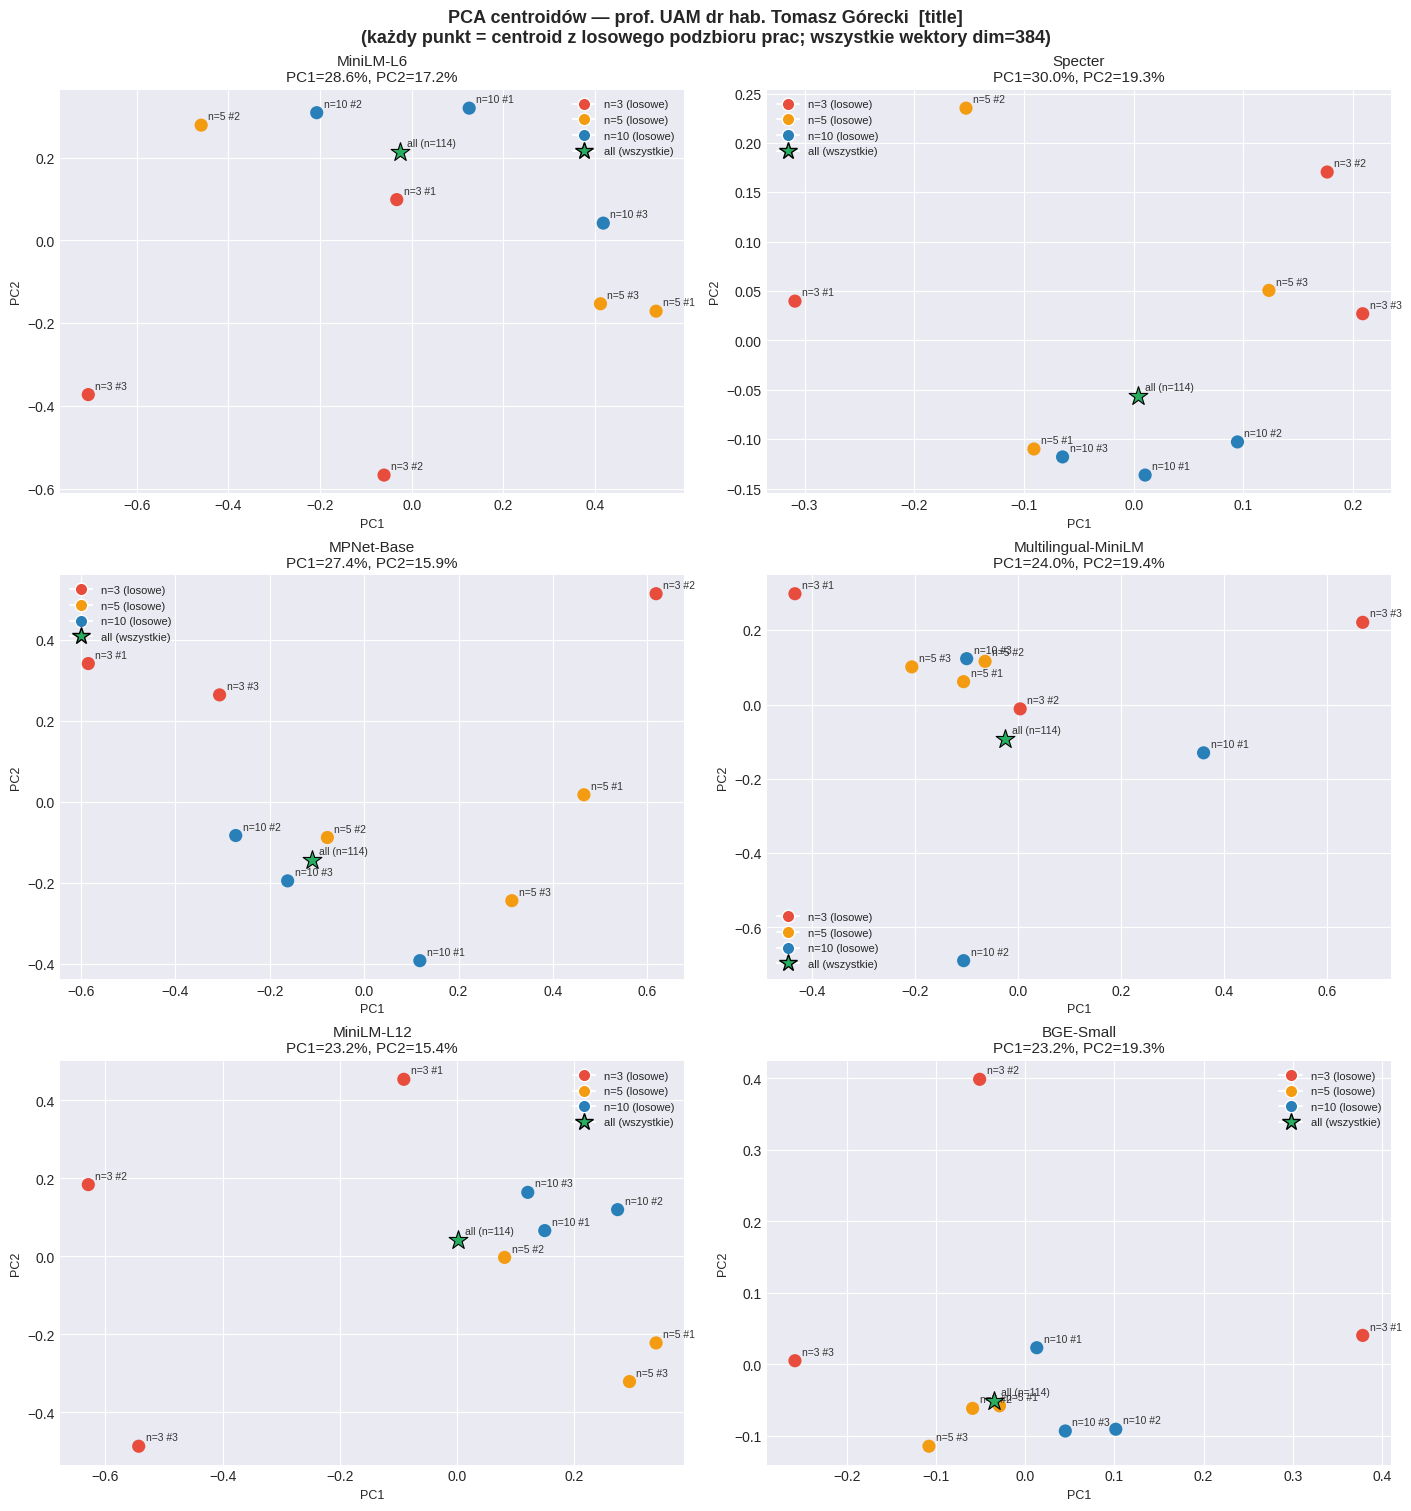

✅ Wykres PCA zapisany.


In [7]:
# ── PCA: jeden wykres na model ────────────────────────────────────────────────

SIZE_COLORS = {
    3:   '#e74c3c',
    5:   '#f39c12',
    10:  '#2980b9',
}
COLOR_ALL = '#27ae60'

n_models = len(centroids)
n_cols   = 2
n_rows   = (n_models + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(7 * n_cols, 5 * n_rows),
                          constrained_layout=True)
axes_flat = axes.flatten()

fig.suptitle(f'PCA centroidów — {TARGET_NAME}  [{EMB_TYPE}]\n'
             f'(każdy punkt = centroid z losowego podzbioru prac; wszystkie wektory dim={TARGET_DIM})',
             fontsize=13, fontweight='bold')

for ax_i, (model_short, entries) in enumerate(centroids.items()):
    ax     = axes_flat[ax_i]
    vecs   = np.array([e['centroid'] for e in entries])
    vecs_n = normalize(vecs, norm='l2')

    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vecs_n)

    for e, (x, y) in zip(entries, coords):
        is_all = (e['repeat'] == 0)
        color  = COLOR_ALL if is_all else SIZE_COLORS.get(e['size'], '#888')
        ax.scatter(x, y,
                   c=color,
                   s=200 if is_all else 90,
                   marker='*' if is_all else 'o',
                   zorder=5 if is_all else 3,
                   edgecolors='k' if is_all else 'none',
                   linewidths=0.8)
        ax.annotate(e['label'], (x, y),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=7.5, color='#333')

    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=SIZE_COLORS[s],
               markersize=9, label=f'n={s} (losowe)')
        for s in SAMPLE_SIZES if any(e['size']==s for e in entries)
    ] + [
        Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_ALL,
               markersize=13, markeredgecolor='k', label='all (wszystkie)')
    ]
    ax.legend(handles=handles, fontsize=8)

    var = pca.explained_variance_ratio_
    ax.set_title(f'{model_short}\nPC1={var[0]:.1%}, PC2={var[1]:.1%}', fontsize=11)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)

for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.savefig('pca_centroid_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Wykres PCA zapisany.')

## Podobieństwo cosinusowe między centroidami

Dla każdego modelu/typu obliczamy macierz podobieństw cosinusowych między wszystkimi centroidami.
Chcemy zobaczyć, przy jakiej liczbie prac centroidy przestają drastycznie różnić się od centroidu
zbudowanego ze wszystkich prac.

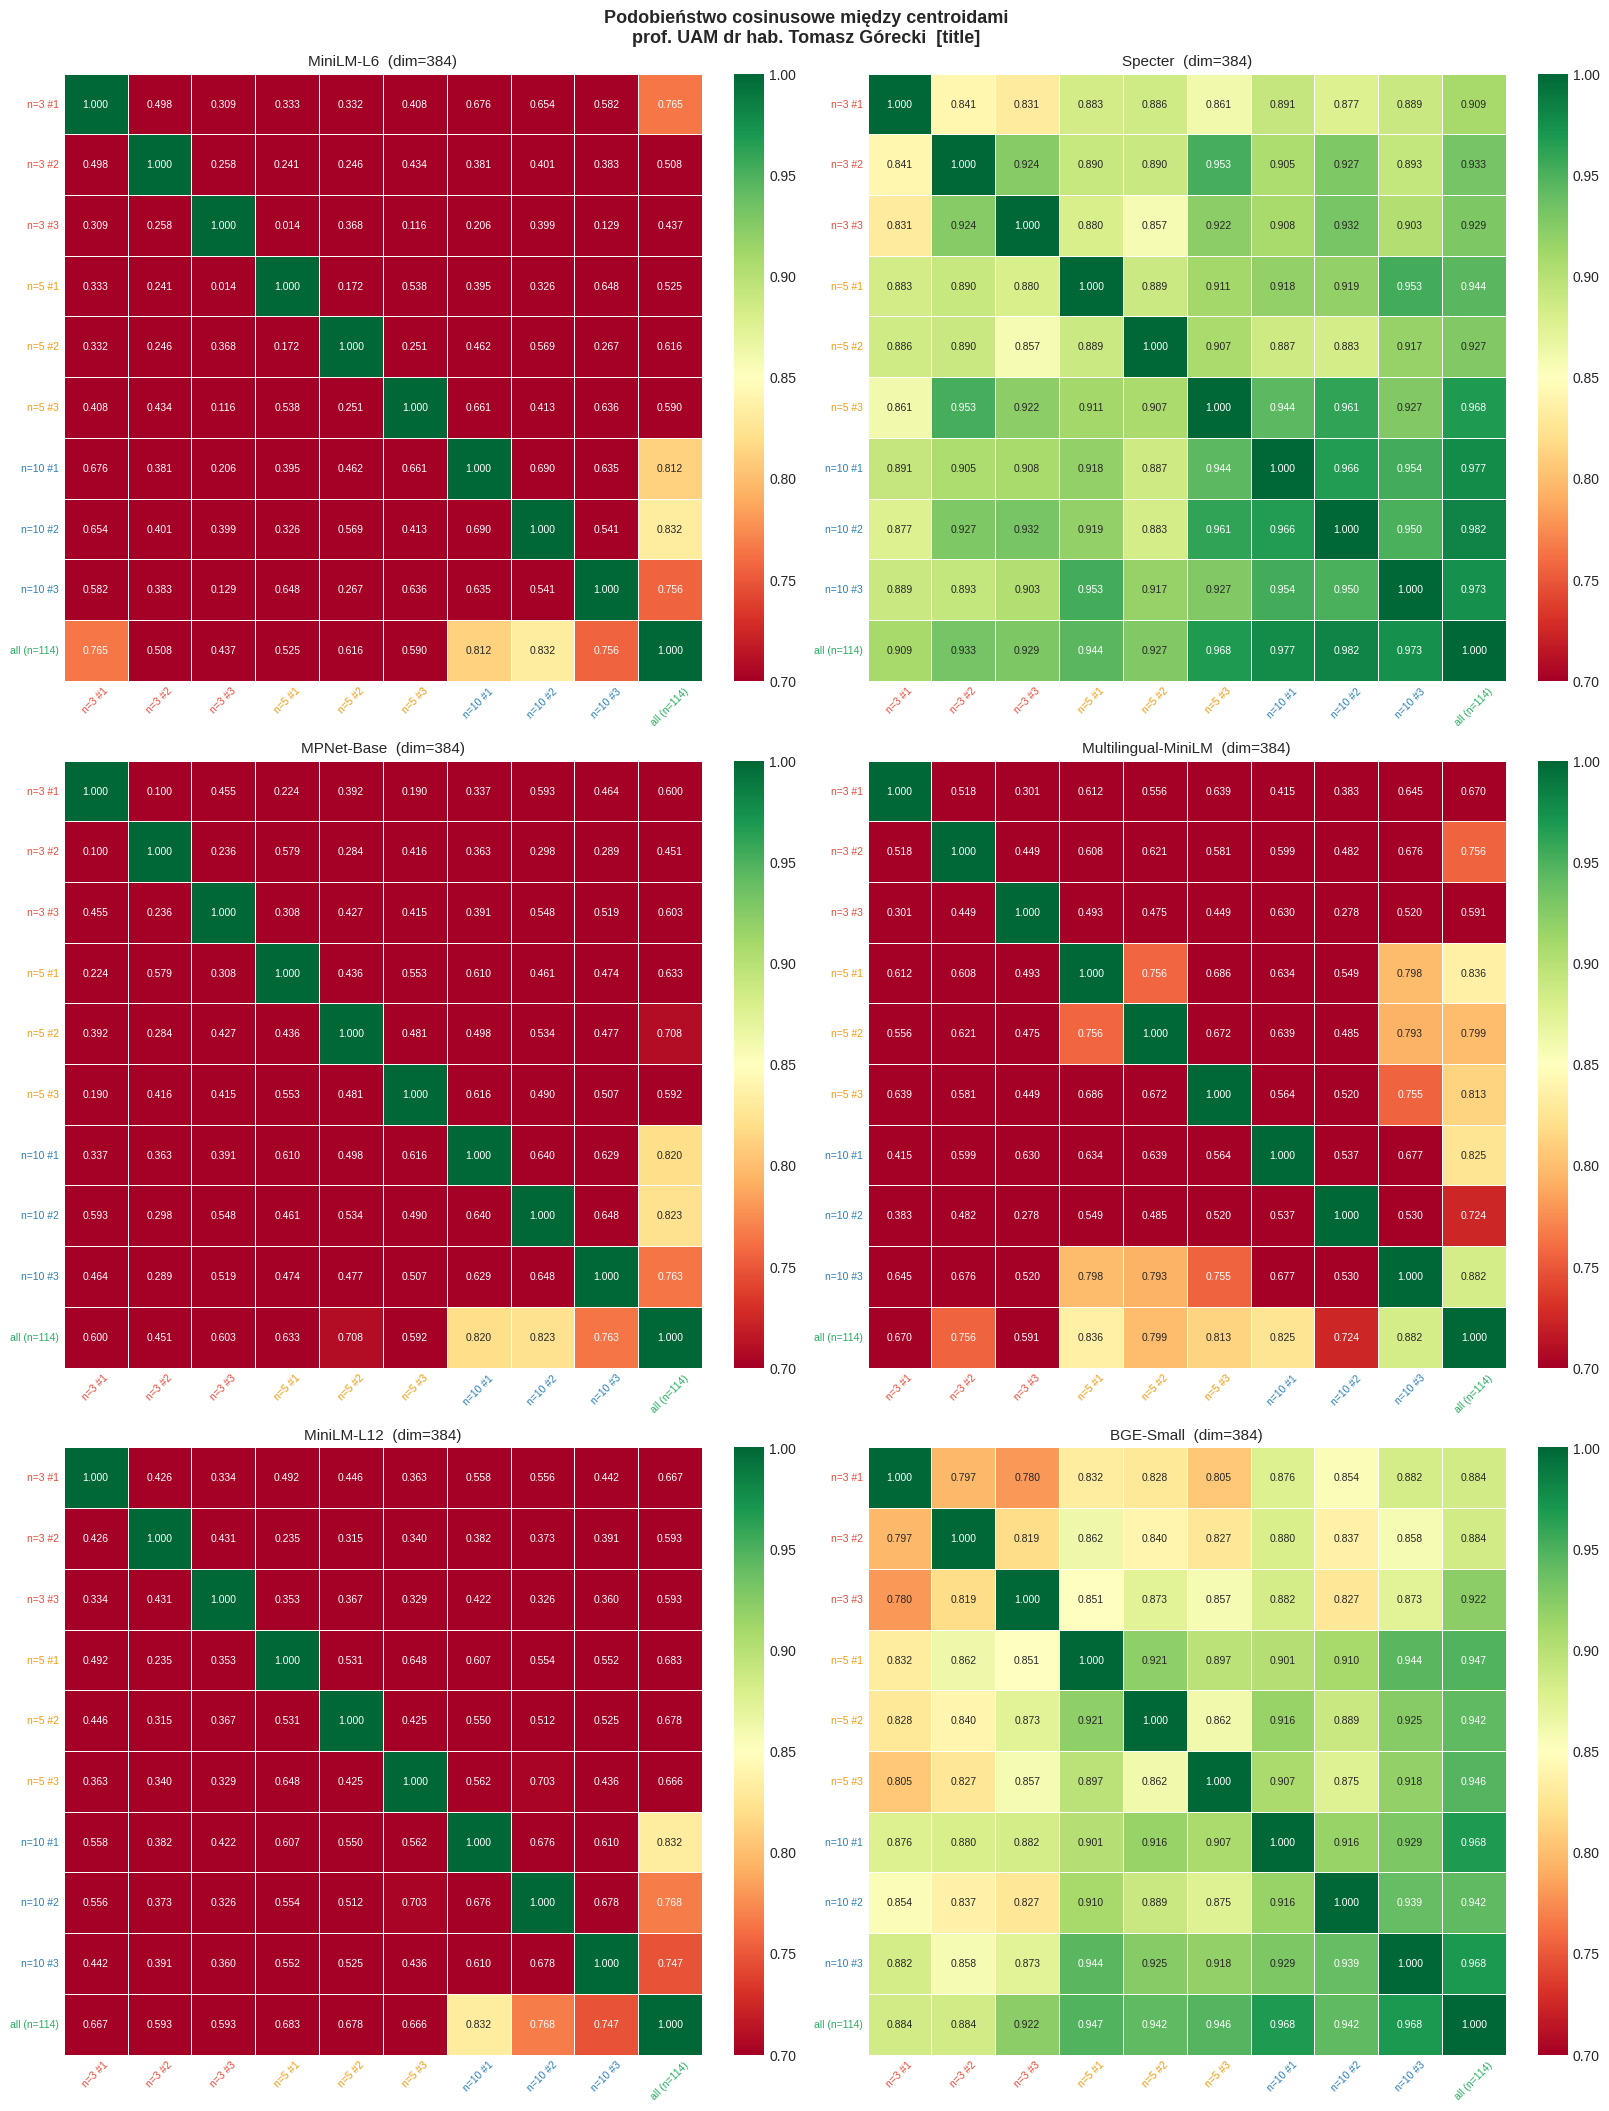

✅ Heatmapy zapisane.


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# ── Heatmapy macierzy cosinusowych ────────────────────────────────────────────
# Jeden subplot na model; oś = wszystkie 10 centroidów (n=3×3, n=5×3, n=10×3, all×1)

n_models = len(centroids)
n_cols   = 2
n_rows   = (n_models + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(8 * n_cols, 7 * n_rows),
                          constrained_layout=True)
axes_flat = axes.flatten()

fig.suptitle(f'Podobieństwo cosinusowe między centroidami\n{TARGET_NAME}  [{EMB_TYPE}]',
             fontsize=13, fontweight='bold')

for ax_i, (model_short, entries) in enumerate(centroids.items()):
    ax     = axes_flat[ax_i]
    labels = [e['label'] for e in entries]
    vecs   = np.array([e['centroid'] for e in entries])

    sim_matrix = cosine_similarity(vecs)

    # Kolorowanie etykiet wg rozmiaru
    tick_colors = []
    for e in entries:
        if e['repeat'] == 0:
            tick_colors.append(COLOR_ALL)
        else:
            tick_colors.append(SIZE_COLORS.get(e['size'], '#333'))

    sns.heatmap(sim_matrix,
                ax=ax,
                annot=True, fmt='.3f',
                xticklabels=labels, yticklabels=labels,
                cmap='RdYlGn',
                vmin=0.7, vmax=1.0,
                linewidths=0.4,
                annot_kws={'size': 7.5})

    ax.set_title(f'{model_short}  (dim={entries[0]["centroid"].shape[0]})', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=7.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=7.5)

    # Pokoloruj etykiety osi
    for tick, color in zip(ax.get_xticklabels(), tick_colors):
        tick.set_color(color)
    for tick, color in zip(ax.get_yticklabels(), tick_colors):
        tick.set_color(color)

for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.savefig('cosine_similarity_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmapy zapisane.')

---
## Eksperyment rozszerzony: gęste próbkowanie kombinacji

Zamiast 3 powtórzeń na rozmiar, generujemy **dużo** losowych podzbiorów prac
(do `MAX_COMBOS_PER_SIZE` kombinacji) i oglądamy jak cała chmura centroidów wygląda
na PCA oraz jak rozkładają się podobieństwa cosinusowe wewnątrz każdej grupy.

Uwaga: dla Góreckiego (114 prac) przestrzeń kombinacji jest ogromna
(np. C(114,3) ≈ 240k), więc zawsze próbkujemy — nie enumerujemy wyczerpująco.

In [9]:
from math import comb as n_combinations

# ── Konfiguracja rozszerzonego eksperymentu ────────────────────────────────────
EXP2_SAMPLE_SIZES   = [3, 5, 10, 20, 30, 50, 100, 150]
MAX_COMBOS_PER_SIZE = 300
EXP2_SEED           = 123

n_works = len(gorecki_ids)

# Odfiltruj rozmiary większe niż liczba dostępnych prac
valid_sizes   = [s for s in EXP2_SAMPLE_SIZES if s <= n_works]
skipped_sizes = [s for s in EXP2_SAMPLE_SIZES if s >  n_works]

print(f'📋 Konfiguracja eksperymentu rozszerzonego:')
print(f'   Modele:          {list(MODELS.keys())}')
print(f'   Rozmiary (żądane):  {EXP2_SAMPLE_SIZES}')
if skipped_sizes:
    print(f'   ⚠  Pominięte (> n_works={n_works}): {skipped_sizes}')
print(f'   Rozmiary (aktywne): {valid_sizes}')
print(f'   Max kombinacji:  {MAX_COMBOS_PER_SIZE}')
print()

print(f'Przestrzeń kombinacji (n_works={n_works}):')
for s in valid_sizes:
    total = n_combinations(n_works, s)
    taken = min(total, MAX_COMBOS_PER_SIZE)
    pct   = taken / total * 100
    print(f'   C({n_works},{s:3d}) = {total:>20,}  →  próbkujemy {taken} ({pct:.4f}%)')

📋 Konfiguracja eksperymentu rozszerzonego:
   Modele:          ['MiniLM-L6', 'Specter', 'MPNet-Base', 'Multilingual-MiniLM', 'MiniLM-L12', 'BGE-Small']
   Rozmiary (żądane):  [3, 5, 10, 20, 30, 50, 100, 150]
   ⚠  Pominięte (> n_works=114): [150]
   Rozmiary (aktywne): [3, 5, 10, 20, 30, 50, 100]
   Max kombinacji:  300

Przestrzeń kombinacji (n_works=114):
   C(114,  3) =              240,464  →  próbkujemy 300 (0.1248%)
   C(114,  5) =          146,803,272  →  próbkujemy 300 (0.0002%)
   C(114, 10) =   68,058,620,813,106  →  próbkujemy 300 (0.0000%)
   C(114, 20) = 9,614,827,842,888,512,530,440  →  próbkujemy 300 (0.0000%)
   C(114, 30) = 2,893,329,493,036,872,394,914,204,488  →  próbkujemy 300 (0.0000%)
   C(114, 50) = 659,098,269,441,164,911,071,480,492,639,771  →  próbkujemy 300 (0.0000%)
   C(114,100) = 312,629,484,400,483,356  →  próbkujemy 300 (0.0000%)


In [10]:
# ── Budowanie gęstego zbioru centroidów dla wszystkich modeli ─────────────────

rng2 = np.random.default_rng(EXP2_SEED)

exp2_data = {}

for model_short in MODELS:
    emb_map = load_all_embeddings_for_scientist(gorecki_ids, model_short, EMB_TYPE)
    all_ids = list(emb_map.keys())
    raw_dim = next(iter(emb_map.values())).shape[0]

    if raw_dim != TARGET_DIM:
        emb_map = {oid: resize_embedding(emb, TARGET_DIM) for oid, emb in emb_map.items()}

    entries = []

    for size in valid_sizes:
        total        = n_combinations(len(all_ids), size)
        n_take       = min(total, MAX_COMBOS_PER_SIZE)
        seen         = set()
        max_attempts = n_take * 20

        attempts = 0
        while len(seen) < n_take and attempts < max_attempts:
            sampled = tuple(sorted(rng2.choice(all_ids, size=size, replace=False).tolist()))
            attempts += 1
            if sampled in seen:
                continue
            seen.add(sampled)
            entries.append({
                'size':     size,
                'centroid': build_centroid([emb_map[oid] for oid in sampled]),
            })

        if len(seen) < n_take:
            print(f'   ⚠  {model_short} / n={size}: tylko {len(seen)}/{n_take} unikalnych')

    # Centroid ze wszystkich prac
    entries.append({
        'size':     len(all_ids),
        'centroid': build_centroid([emb_map[oid] for oid in all_ids]),
    })

    exp2_data[model_short] = {'entries': entries, 'all_ids': all_ids}

print('✅ Centroidy zbudowane:')
from collections import Counter
for ms, d in exp2_data.items():
    cnt   = Counter(e['size'] for e in d['entries'])
    n_all = len(d['all_ids'])
    parts = ', '.join(
        f'all:{c}' if s == n_all else f'n={s}:{c}'
        for s, c in sorted(cnt.items())
    )
    print(f'   {ms:12s}  →  {len(d["entries"])} centroidów  [{parts}]')

✅ Centroidy zbudowane:
   MiniLM-L6     →  2101 centroidów  [n=3:300, n=5:300, n=10:300, n=20:300, n=30:300, n=50:300, n=100:300, all:1]
   Specter       →  2101 centroidów  [n=3:300, n=5:300, n=10:300, n=20:300, n=30:300, n=50:300, n=100:300, all:1]
   MPNet-Base    →  2101 centroidów  [n=3:300, n=5:300, n=10:300, n=20:300, n=30:300, n=50:300, n=100:300, all:1]
   Multilingual-MiniLM  →  2101 centroidów  [n=3:300, n=5:300, n=10:300, n=20:300, n=30:300, n=50:300, n=100:300, all:1]
   MiniLM-L12    →  2101 centroidów  [n=3:300, n=5:300, n=10:300, n=20:300, n=30:300, n=50:300, n=100:300, all:1]
   BGE-Small     →  2101 centroidów  [n=3:300, n=5:300, n=10:300, n=20:300, n=30:300, n=50:300, n=100:300, all:1]


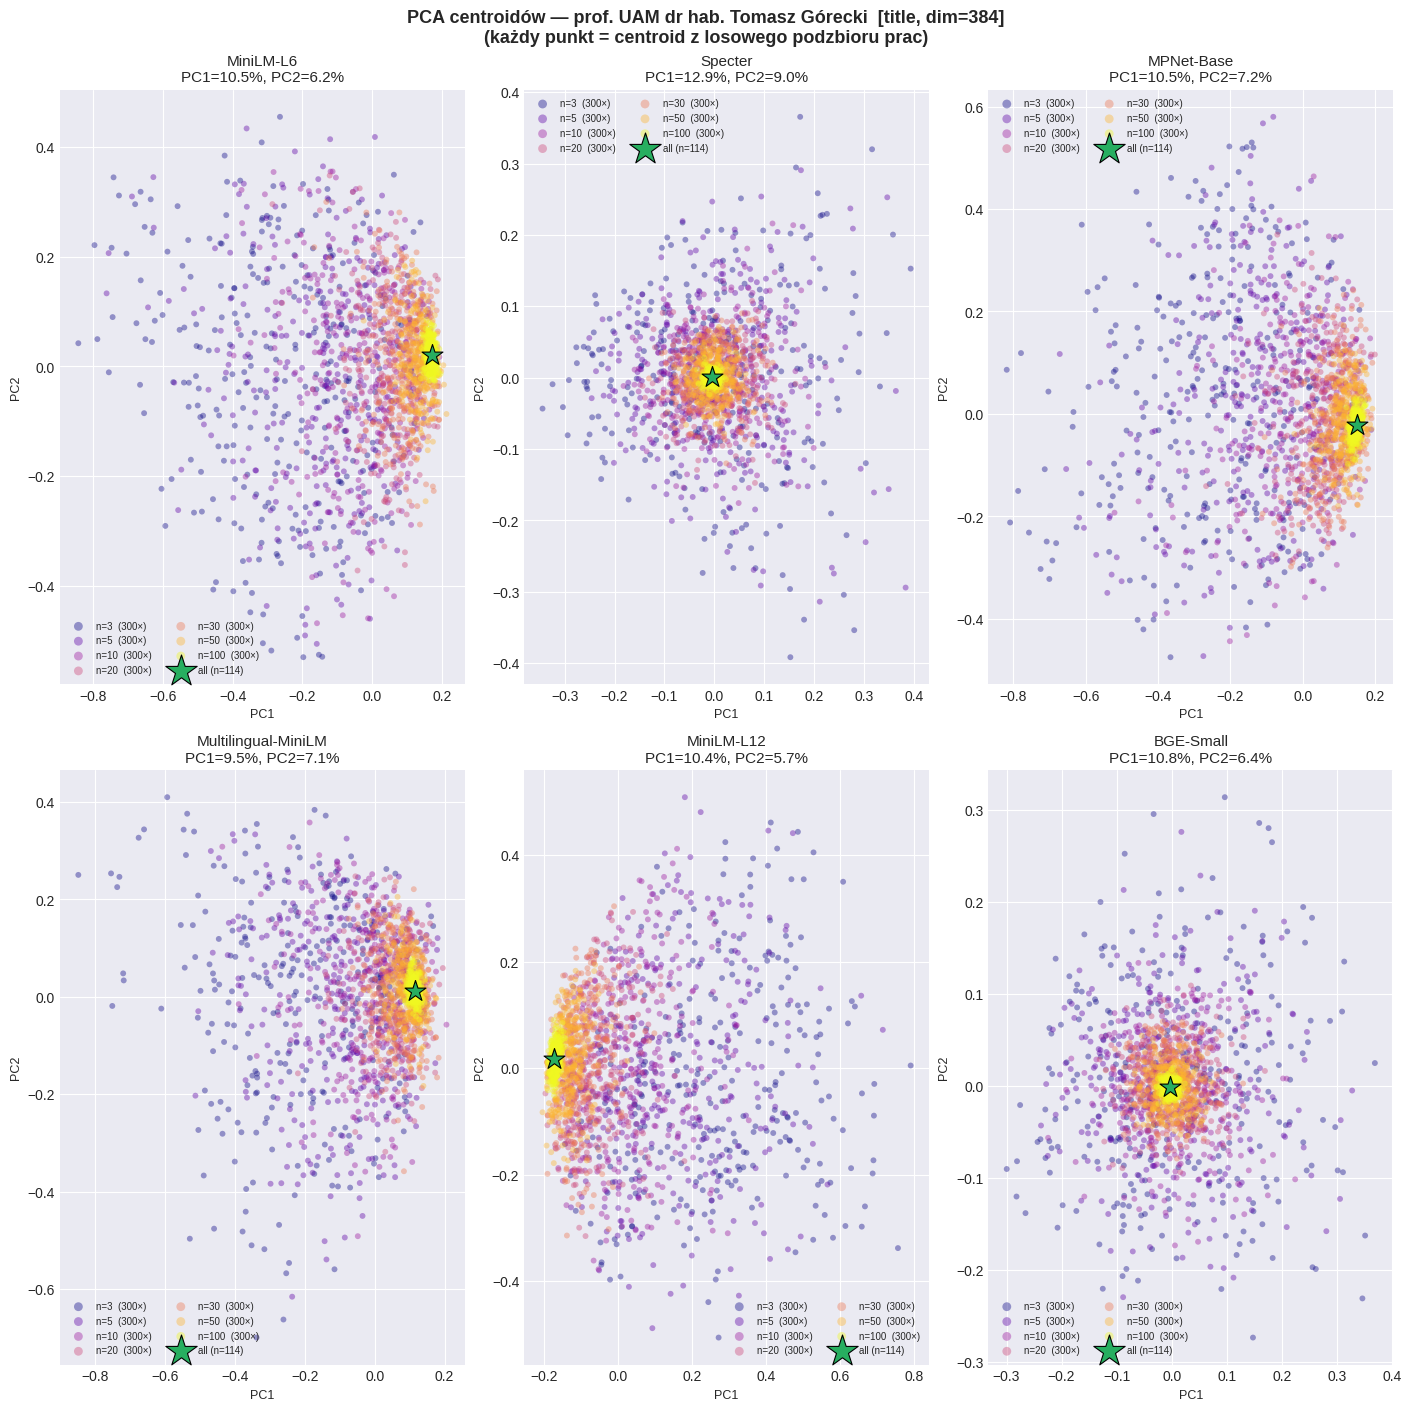

✅ PCA zapisana.


In [11]:
# ── PCA: chmura centroidów — siatka 2×2 (jeden panel na model) ───────────────

# Kolory generowane dynamicznie z colormapy dla valid_sizes + osobny kolor dla "all"
_cmap       = plt.cm.plasma
_size_colors = {s: _cmap(i / max(len(valid_sizes) - 1, 1))
                for i, s in enumerate(valid_sizes)}
_color_all  = '#27ae60'

def size_color(size, n_all):
    return _color_all if size == n_all else _size_colors.get(size, '#888888')

n_models = len(exp2_data)
fig, axes = plt.subplots(2, 3, figsize=(14, 14), constrained_layout=True)
axes_flat = axes.flatten()

fig.suptitle(
    f'PCA centroidów — {TARGET_NAME}  [{EMB_TYPE}, dim={TARGET_DIM}]\n'
    f'(każdy punkt = centroid z losowego podzbioru prac)',
    fontsize=13, fontweight='bold'
)

for ax_i, (model_short, d) in enumerate(exp2_data.items()):
    ax      = axes_flat[ax_i]
    entries = d['entries']
    n_all   = len(d['all_ids'])

    vecs   = np.array([e['centroid'] for e in entries])
    vecs_n = normalize(vecs, norm='l2')
    pca_   = PCA(n_components=2, random_state=42)
    coords = pca_.fit_transform(vecs_n)
    var    = pca_.explained_variance_ratio_

    # Rysuj od najmniejszego do największego, "all" na wierzchu
    for size in sorted(_size_colors.keys()) + [n_all]:
        mask   = [e['size'] == size for e in entries]
        if not any(mask):
            continue
        pts    = coords[mask]
        is_all = (size == n_all)
        color  = size_color(size, n_all)
        label  = f'all (n={size})' if is_all else f'n={size}  ({sum(mask)}×)'
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=[color],
                   s=250 if is_all else 18,
                   marker='*' if is_all else 'o',
                   alpha=1.0 if is_all else 0.4,
                   edgecolors='k' if is_all else 'none',
                   linewidths=0.8,
                   label=label,
                   zorder=10 if is_all else 2)

    ax.set_title(f'{model_short}\nPC1={var[0]:.1%}, PC2={var[1]:.1%}', fontsize=11)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.legend(fontsize=7, markerscale=1.5, ncol=2)

for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.savefig('pca_dense_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PCA zapisana.')

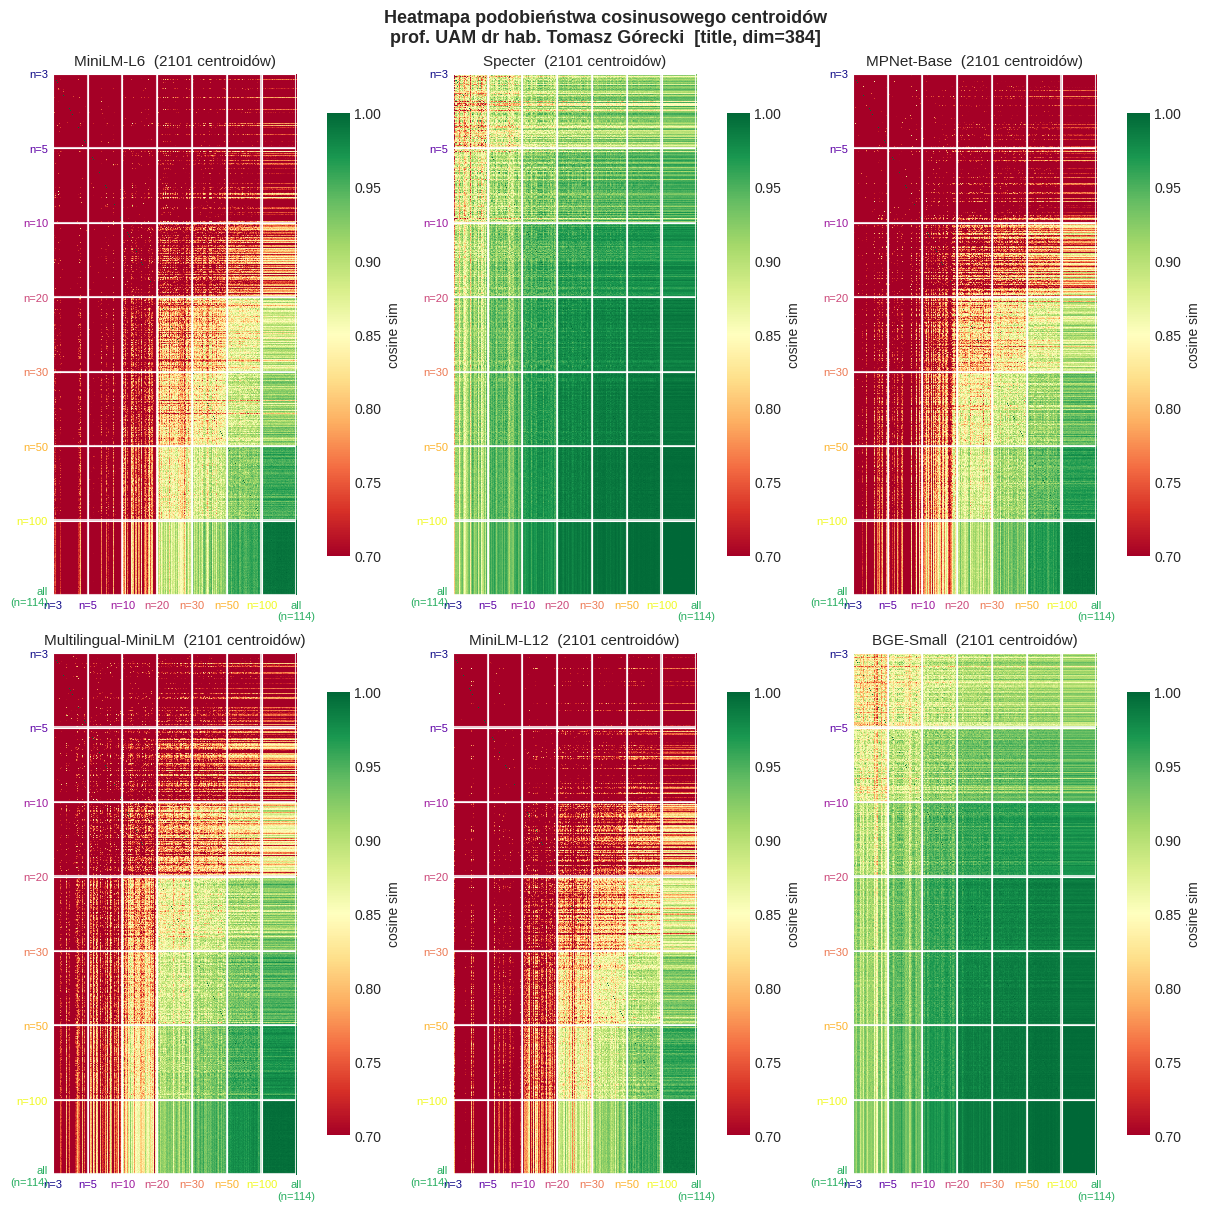

✅ Heatmapa zapisana.


In [24]:
# ── Heatmapa podobieństwa cosinusowego — siatka 2×2 ──────────────────────────

from sklearn.metrics.pairwise import cosine_similarity as cos_sim_mat

fig, axes = plt.subplots(2, 3, figsize=(12, 12), constrained_layout=True)
axes_flat = axes.flatten()

fig.suptitle(
    f'Heatmapa podobieństwa cosinusowego centroidów\n'
    f'{TARGET_NAME}  [{EMB_TYPE}, dim={TARGET_DIM}]',
    fontsize=13, fontweight='bold'
)

for ax_i, (model_short, d) in enumerate(exp2_data.items()):
    ax      = axes_flat[ax_i]
    entries = d['entries']
    n_all   = len(d['all_ids'])

    order          = sorted(range(len(entries)), key=lambda i: entries[i]['size'])
    entries_sorted = [entries[i] for i in order]
    sizes_sorted   = [e['size'] for e in entries_sorted]

    vecs_s  = np.array([e['centroid'] for e in entries_sorted])
    sim_mat = cos_sim_mat(vecs_s)

    im = ax.imshow(sim_mat, cmap='RdYlGn', vmin=0.7, vmax=1.0,
                   aspect='auto', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='cosine sim', shrink=0.85)

    tick_positions, tick_labels, tick_colors = [], [], []
    prev = None
    for i, s in enumerate(sizes_sorted):
        if s != prev:
            tick_positions.append(i)
            tick_labels.append(f'all\n(n={s})' if s == n_all else f'n={s}')
            tick_colors.append(_color_all if s == n_all else _size_colors.get(s, '#333'))
            if prev is not None:
                ax.axhline(i - 0.5, color='white', linewidth=1.5, alpha=0.8)
                ax.axvline(i - 0.5, color='white', linewidth=1.5, alpha=0.8)
            prev = s

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, fontsize=8)

    for tick, color in zip(ax.get_xticklabels(), tick_colors):
        tick.set_color(color)
    for tick, color in zip(ax.get_yticklabels(), tick_colors):
        tick.set_color(color)

    ax.set_title(f'{model_short}  ({len(entries)} centroidów)', fontsize=11)

for ax in axes_flat[len(exp2_data):]:
    ax.set_visible(False)

plt.savefig('heatmap_dense_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmapa zapisana.')

In [13]:
# ── Tabela: średnie podobieństwo cosinusowe do centroidu "all" ────────────────
# Dla każdego modelu i każdego rozmiaru próbki liczymy:
#   mean / std / min / max  podobieństwa sim(centroid_n, centroid_all)

from sklearn.metrics.pairwise import cosine_similarity as cos_sim_mat

rows = []
for model_short, d in exp2_data.items():
    entries = d['entries']
    n_all   = len(d['all_ids'])

    c_all = next(e['centroid'] for e in entries if e['size'] == n_all).reshape(1, -1)

    for size in valid_sizes:
        vecs = np.array([e['centroid'] for e in entries if e['size'] == size])
        if len(vecs) == 0:
            continue
        sims = cos_sim_mat(vecs, c_all).flatten()
        rows.append({
            'Model':    model_short,
            'n prac':   size,
            'n próbek': len(sims),
            'mean':     np.mean(sims),
            'std':      np.std(sims),
            'min':      np.min(sims),
            'max':      np.max(sims),
        })

df_exp2 = (pd.DataFrame(rows)
           .sort_values(['Model', 'n prac'])
           .reset_index(drop=True))

for col in ['mean', 'std', 'min', 'max']:
    df_exp2[col] = df_exp2[col].round(4)

# ── Wyświetl jako pivot: wiersze = n prac, kolumny = modele ──────────────────
pivot = df_exp2.pivot(index='n prac', columns='Model', values='mean')
pivot.columns.name = None
pivot.index.name   = 'n prac'

print('Średnie podobieństwo cosinusowe  sim(centroid_n, centroid_all)\n')
print(pivot.round(4).to_string())

print('\n\nSzczegółowa tabela (mean ± std):')
for model_short in MODELS:
    subset = df_exp2[df_exp2['Model'] == model_short]
    print(f'\n  {model_short}:')
    print(f'  {"n prac":>8}  {"n próbek":>9}  {"mean":>7}  {"std":>7}  {"min":>7}  {"max":>7}')
    print(f'  {"-"*55}')
    for _, row in subset.iterrows():
        print(f'  {int(row["n prac"]):>8}  {int(row["n próbek"]):>9}  '
              f'{row["mean"]:>7.4f}  {row["std"]:>7.4f}  '
              f'{row["min"]:>7.4f}  {row["max"]:>7.4f}')

Średnie podobieństwo cosinusowe  sim(centroid_n, centroid_all)

        BGE-Small  MPNet-Base  MiniLM-L12  MiniLM-L6  Multilingual-MiniLM  Specter
n prac                                                                            
3          0.9075      0.5698      0.5290     0.5304               0.6290   0.9129
5          0.9420      0.6698      0.6422     0.6441               0.7352   0.9427
10         0.9720      0.8051      0.7717     0.7670               0.8387   0.9729
20         0.9868      0.8953      0.8761     0.8738               0.9194   0.9872
30         0.9921      0.9348      0.9209     0.9154               0.9494   0.9922
50         0.9964      0.9685      0.9609     0.9608               0.9759   0.9965
100        0.9996      0.9964      0.9956     0.9956               0.9973   0.9996


Szczegółowa tabela (mean ± std):

  MiniLM-L6:
    n prac   n próbek     mean      std      min      max
  -------------------------------------------------------
         3        300   

---
## Eksperyment zbiorczy: top-N naukowców

Dla każdego z top-N naukowców (wg liczby prac) i każdego modelu generujemy losowe podzbiory
prac i mierzymy podobieństwo cosinusowe centroidu próbki do centroidu pełnego.
Wyniki uśredniamy po naukowcach — chcemy dowiedzieć się **przy ilu pracach centroid zaczyna
być stabilny niezależnie od tego, którego naukowca badamy**.

In [18]:
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim

# ── Konfiguracja ───────────────────────────────────────────────────────────────
TOP_N_SCIENTISTS     = 999   # ilu top naukowców wziąć (wg liczby prac)
EXP3_SAMPLE_SIZES    = [3, 5, 10, 20, 50, 100]
N_COMBOS_PER_SIZE    = 10    # ile losowych próbek na rozmiar na naukowca
MIN_WORKS_SCIENTIST  = 3     # minimum prac żeby włączyć naukowca
EXP3_SEED            = 42

# ── Wybór top-N naukowców ──────────────────────────────────────────────────────
works_per_orcid = (df_works
                   .dropna(subset=['clean_orcid', 'openalex_id'])
                   .groupby('clean_orcid')['openalex_id']
                   .apply(list))

# Ogranicz do naukowców ze zbioru scientists_with_identifiers
known_orcids = set(df_scientists['clean_orcid'].dropna())
works_per_orcid = works_per_orcid[works_per_orcid.index.isin(known_orcids)]

# Top N wg liczby prac, minimum MIN_WORKS_SCIENTIST
top_orcids = (works_per_orcid
              .apply(len)
              .sort_values(ascending=False)
              [lambda s: s >= MIN_WORKS_SCIENTIST]
              .head(TOP_N_SCIENTISTS)
              .index.tolist())

orcid_to_name = dict(zip(df_scientists['clean_orcid'], df_scientists['full_name']))

print(f'📋 Konfiguracja eksperymentu zbiorczego:')
print(f'   Top naukowców:    {len(top_orcids)} (z {TOP_N_SCIENTISTS} żądanych)')
print(f'   Modele:           {list(MODELS.keys())}')
print(f'   Rozmiary próbek:  {EXP3_SAMPLE_SIZES}')
print(f'   Próbek/rozmiar:   {N_COMBOS_PER_SIZE}')
print()
print('Rozkład liczby prac wśród wybranych naukowców:')
counts = sorted([len(works_per_orcid[o]) for o in top_orcids], reverse=True)
print(f'   max={counts[0]}, mediana={int(np.median(counts))}, '
      f'min={counts[-1]}, ≥100 prac: {sum(c >= 100 for c in counts)}')

📋 Konfiguracja eksperymentu zbiorczego:
   Top naukowców:    107 (z 999 żądanych)
   Modele:           ['MiniLM-L6', 'Specter', 'MPNet-Base', 'Multilingual-MiniLM', 'MiniLM-L12', 'BGE-Small']
   Rozmiary próbek:  [3, 5, 10, 20, 50, 100]
   Próbek/rozmiar:   10

Rozkład liczby prac wśród wybranych naukowców:
   max=199, mediana=20, min=3, ≥100 prac: 6


In [19]:
# ── Główna pętla ───────────────────────────────────────────────────────────────
# Dla każdego naukowca × model × size obliczamy mean(sim(centroid_n, centroid_all)).
# Wynik: lista rekordów do DataFrame.

rng3 = np.random.default_rng(EXP3_SEED)
exp3_rows = []

n_total = len(top_orcids) * len(MODELS)
done    = 0

for orcid in top_orcids:
    work_ids = works_per_orcid[orcid]

    for model_short in MODELS:
        done += 1
        if done % 50 == 0 or done == n_total:
            print(f'   [{done}/{n_total}]  {orcid_to_name.get(orcid, orcid)[:40]} / {model_short}')

        # Wczytaj embeddingi
        emb_map = load_all_embeddings_for_scientist(work_ids, model_short, EMB_TYPE)
        all_ids = list(emb_map.keys())

        if len(all_ids) < MIN_WORKS_SCIENTIST:
            continue

        # Resize jeśli potrzeba
        raw_dim = next(iter(emb_map.values())).shape[0]
        if raw_dim != TARGET_DIM:
            emb_map = {oid: resize_embedding(emb, TARGET_DIM)
                       for oid, emb in emb_map.items()}

        # Centroid ze wszystkich prac
        c_all = build_centroid([emb_map[oid] for oid in all_ids]).reshape(1, -1)

        for size in EXP3_SAMPLE_SIZES:
            if size > len(all_ids):
                continue   # ten naukowiec ma za mało prac

            sims    = []
            seen    = set()
            attempts = 0
            max_att  = N_COMBOS_PER_SIZE * 20

            while len(sims) < N_COMBOS_PER_SIZE and attempts < max_att:
                sampled = tuple(sorted(
                    rng3.choice(all_ids, size=size, replace=False).tolist()
                ))
                attempts += 1
                if sampled in seen:
                    continue
                seen.add(sampled)
                c_n  = build_centroid([emb_map[oid] for oid in sampled]).reshape(1, -1)
                sims.append(float(_cos_sim(c_n, c_all)[0, 0]))

            if sims:
                exp3_rows.append({
                    'orcid':      orcid,
                    'model':      model_short,
                    'n_prac':     size,
                    'n_all':      len(all_ids),
                    'mean_sim':   np.mean(sims),
                    'std_sim':    np.std(sims),
                    'n_combos':   len(sims),
                })

df_exp3 = pd.DataFrame(exp3_rows)
print(f'\n✅ Gotowe. Rekordów: {len(df_exp3)}'
      f'  |  Naukowców: {df_exp3["orcid"].nunique()}'
      f'  |  Modeli: {df_exp3["model"].nunique()}')

   [50/642]  prof. dr hab. Leszek Skrzypczak / Specter
   [100/642]  dr Barbara Kołodziejczak / Multilingual-MiniLM
   [150/642]  prof. UAM dr hab. Jerzy Grzybowski / BGE-Small
   [200/642]  prof. UAM dr hab. Maciej Radziejewski / Specter
   [250/642]  prof. UAM dr hab. Karol Leśnik / Multilingual-MiniLM
   [300/642]  prof. UAM dr hab. Sebastian Mariusz Król / BGE-Small
   [350/642]  dr Joanna Siwek / Specter
   [400/642]  dr Sohail Farhangi / Multilingual-MiniLM
   [450/642]  dr Janusz Przewocki / BGE-Small
   [500/642]  prof. UAM dr hab. Artur Michalak / Specter
   [550/642]  dr Vitalii Marchenko / Multilingual-MiniLM
   [600/642]  Aleksandra Sadurska / BGE-Small
   [642/642]  Michał Piotr Junczyk / BGE-Small

✅ Gotowe. Rekordów: 2292  |  Naukowców: 107  |  Modeli: 6


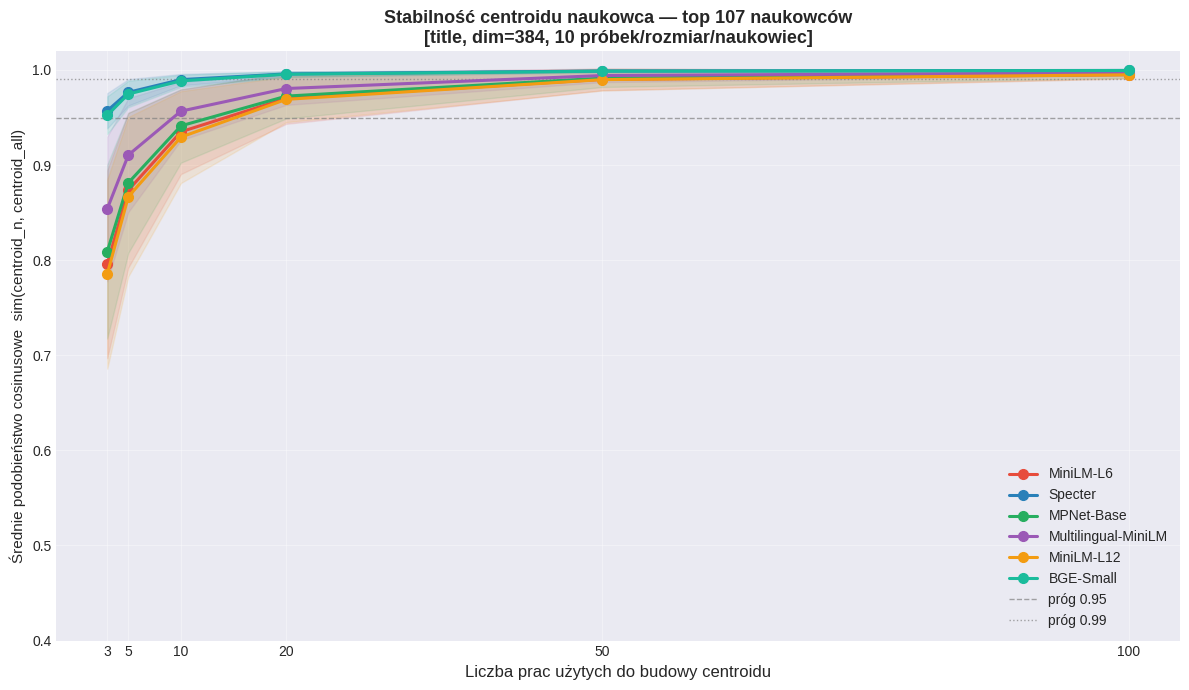

✅ Wykres zapisany.

Średnie podobieństwo cosinusowe (uśrednione po naukowcach):

        MiniLM-L6  Specter  MPNet-Base  Multilingual-MiniLM  MiniLM-L12  BGE-Small
n prac                                                                            
3          0.7958   0.9571      0.8090               0.8539      0.7854     0.9523
5          0.8736   0.9765      0.8813               0.9105      0.8667     0.9747
10         0.9350   0.9898      0.9412               0.9567      0.9294     0.9885
20         0.9701   0.9959      0.9725               0.9805      0.9691     0.9954
50         0.9901   0.9989      0.9914               0.9941      0.9898     0.9987
100        0.9951   0.9995      0.9955               0.9970      0.9949     0.9994

Liczba naukowców (min po modelach) dla każdego rozmiaru próbki:
   n=   3:  107 naukowców
   n=   5:  106 naukowców
   n=  10:  88 naukowców
   n=  20:  55 naukowców
   n=  50:  20 naukowców
   n= 100:  6 naukowców


In [20]:
# ── Agregacja i wizualizacja ───────────────────────────────────────────────────
# Dla każdego (model, n_prac) agregujemy mean_sim po naukowcach.
# Jeden punkt = jeden naukowiec (jego mean_sim dla danego size).

agg = (df_exp3
       .groupby(['model', 'n_prac'])['mean_sim']
       .agg(mean='mean', std='std', median='median',
            q25=lambda x: np.percentile(x, 25),
            q75=lambda x: np.percentile(x, 75),
            n_scientists='count')
       .reset_index())

# Kolejność modeli zgodna z MODELS
model_order = list(MODELS.keys())
model_colors = {m: c for m, c in zip(
    model_order,
    ['#e74c3c', '#2980b9', '#27ae60', '#9b59b6', '#f39c12', '#1abc9c']
)}

fig, ax = plt.subplots(figsize=(12, 7))

for model_short in model_order:
    sub   = agg[agg['model'] == model_short].sort_values('n_prac')
    color = model_colors[model_short]

    ax.plot(sub['n_prac'], sub['mean'], marker='o', linewidth=2.2,
            markersize=7, color=color, label=model_short, zorder=4)

    # Pasmo ±1 std
    ax.fill_between(sub['n_prac'],
                    sub['mean'] - sub['std'],
                    sub['mean'] + sub['std'],
                    alpha=0.12, color=color)

ax.axhline(0.95, color='gray', linestyle='--', linewidth=1,
           alpha=0.7, label='próg 0.95')
ax.axhline(0.99, color='gray', linestyle=':',  linewidth=1,
           alpha=0.7, label='próg 0.99')

ax.set_xlabel('Liczba prac użytych do budowy centroidu', fontsize=12)
ax.set_ylabel('Średnie podobieństwo cosinusowe  sim(centroid_n, centroid_all)', fontsize=11)
ax.set_title(
    f'Stabilność centroidu naukowca — top {len(top_orcids)} naukowców\n'
    f'[{EMB_TYPE}, dim={TARGET_DIM}, {N_COMBOS_PER_SIZE} próbek/rozmiar/naukowiec]',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(EXP3_SAMPLE_SIZES)
ax.set_ylim(0.4, 1.02)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.35)

plt.tight_layout()
plt.savefig('stability_top_scientists.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Wykres zapisany.')

# ── Tabela pivot: mean po naukowcach ──────────────────────────────────────────
pivot3 = agg.pivot(index='n_prac', columns='model', values='mean')[model_order]
pivot3.index.name   = 'n prac'
pivot3.columns.name = None

print('\nŚrednie podobieństwo cosinusowe (uśrednione po naukowcach):\n')
print(pivot3.round(4).to_string())

# Liczba naukowców uwzględnionych w każdym wierszu
n_sci = agg.groupby('n_prac')['n_scientists'].min()
print('\nLiczba naukowców (min po modelach) dla każdego rozmiaru próbki:')
for size, n in n_sci.items():
    print(f'   n={size:>4}:  {n} naukowców')